In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("AIML Dataset.csv")



In [4]:
df["type"] = df["type"].replace({
    "CASH_OUT": "Cash Out",
    "PAYMENT": "Payment",
    "TRANSFER": "Transfer",
    "DEBIT": "Debit",
    "CASH_IN": "Cash In"
})


In [5]:
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,Payment,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,Payment,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,Transfer,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,Cash Out,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,Payment,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
df.columns


Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [8]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [9]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [10]:
df.isnull().sum().sum()
df = df.drop_duplicates()

In [11]:
df.shape

(6362620, 11)

In [12]:
round((df["isFraud"].value_counts()[1] / df.shape[0]) * 100,2)



np.float64(0.13)

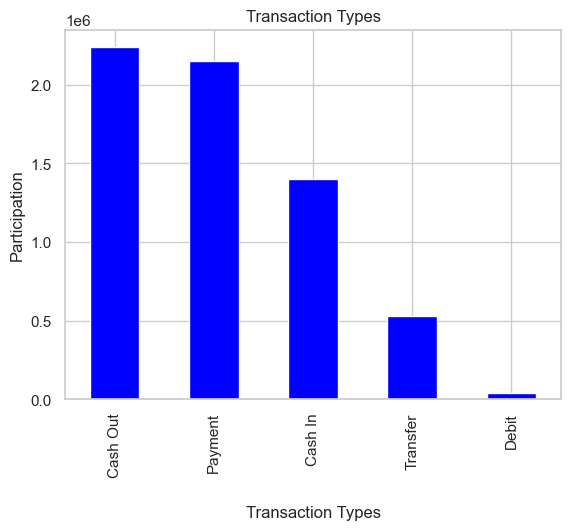

In [13]:
df["type"].value_counts().plot(kind="bar", title="Transaction Types", color = "blue")
plt.xlabel("Transaction Types", labelpad=20)
plt.ylabel("Participation")
plt.show()

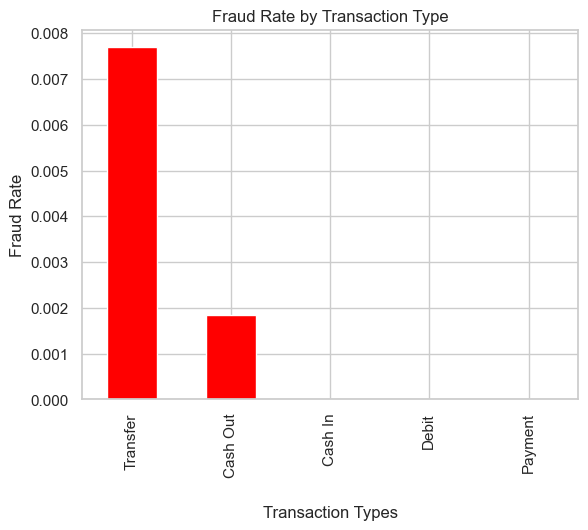

In [14]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud Rate by Transaction Type", color="Red")
plt.xlabel("Transaction Types", labelpad=20)
plt.ylabel("Fraud Rate")
plt.show()


In [15]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

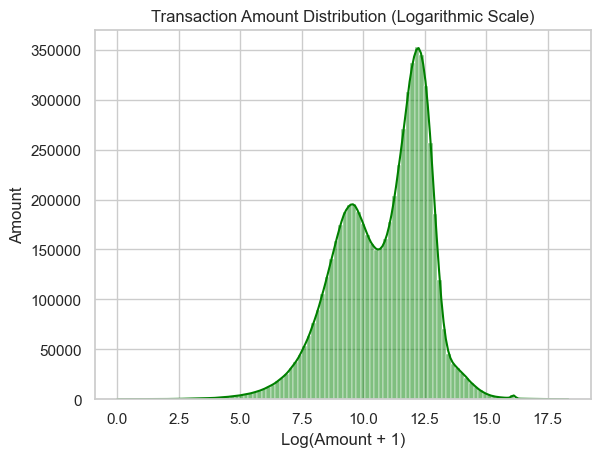

In [16]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde=True, color="green")
plt.title("Transaction Amount Distribution (Logarithmic Scale)")
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Amount")
plt.show()

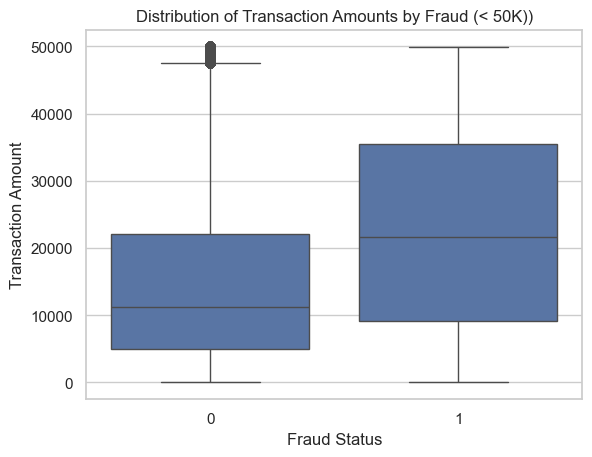

In [17]:
sns.boxplot(data= df[df["amount"] < 50000], x = "isFraud", y = "amount")
plt.title("Distribution of Transaction Amounts by Fraud (< 50K))")
plt.ylabel("Transaction Amount")
plt.xlabel("Fraud Status")
plt.show()

In [18]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [19]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [20]:
(df["balanceDiffOrig"] < 0).sum()

np.int64(1399253)

In [21]:
(df["balanceDiffDest"] < 0).sum()

np.int64(1238864)

In [22]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,Payment,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,Payment,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


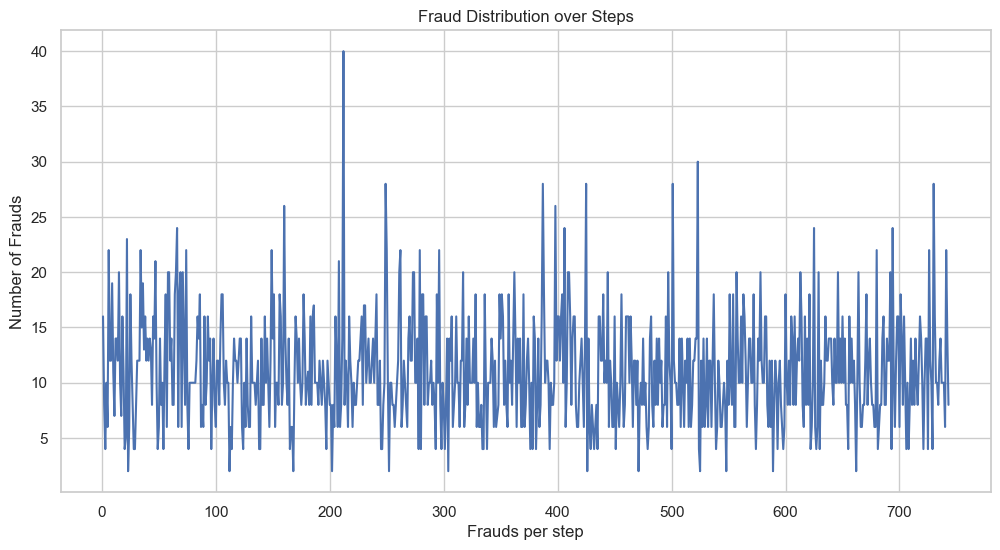

In [23]:
fraud_per_step = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.plot(fraud_per_step.index , fraud_per_step.values, label="Frauds per Step")
plt.xlabel("Frauds per step")
plt.ylabel("Number of Frauds")
plt.title("Fraud Distribution over Steps")
plt.grid(True)
plt.show()


In [24]:
df.drop(columns="step",inplace=True)

In [25]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,Payment,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,Payment,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,Transfer,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,Cash Out,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,Payment,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [26]:
top_senders = df["nameOrig"].value_counts().head(10)

In [27]:
top_senders

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
C1784010646    3
C1530544995    3
C1065307291    3
C545315117     3
C1902386530    3
Name: count, dtype: int64

In [28]:
top_receivers = df["nameDest"].value_counts().head(10)

In [29]:
top_receivers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [30]:
fraud_users = df[df["isFraud"]== 1]["nameOrig"].value_counts().head(10)

In [31]:
fraud_users


nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [32]:
fraud_types = df[df["type"].isin(["Transfer","Cash Out"])]

In [33]:
fraud_types.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,Transfer,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,Cash Out,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,Cash Out,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,Transfer,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,Transfer,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [34]:
fraud_types["type"].value_counts()

type
Cash Out    2237500
Transfer     532909
Name: count, dtype: int64

In [35]:
print(fraud_types.columns)

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')


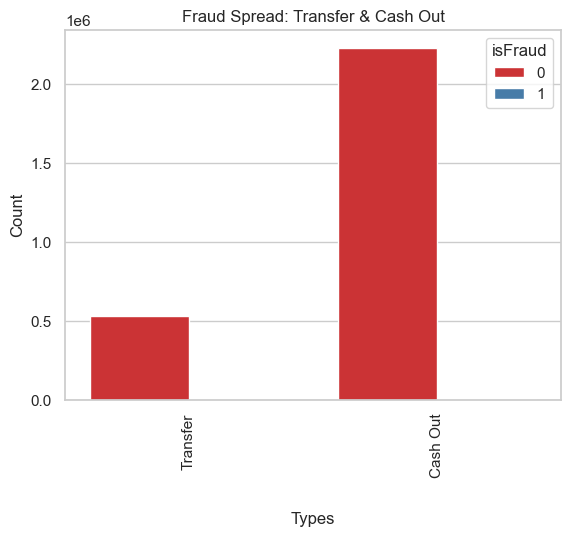

In [38]:
sns.countplot(data=fraud_types, x="type", hue="isFraud", palette="Set1",)
plt.xticks(rotation=90)
plt.title("Fraud Spread: Transfer & Cash Out",)
plt.xlabel("Types", labelpad=25)
plt.ylabel("Count", )
plt.show()


In [39]:
corr = df[["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest", "newbalanceDest","isFraud"]].corr()

In [40]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


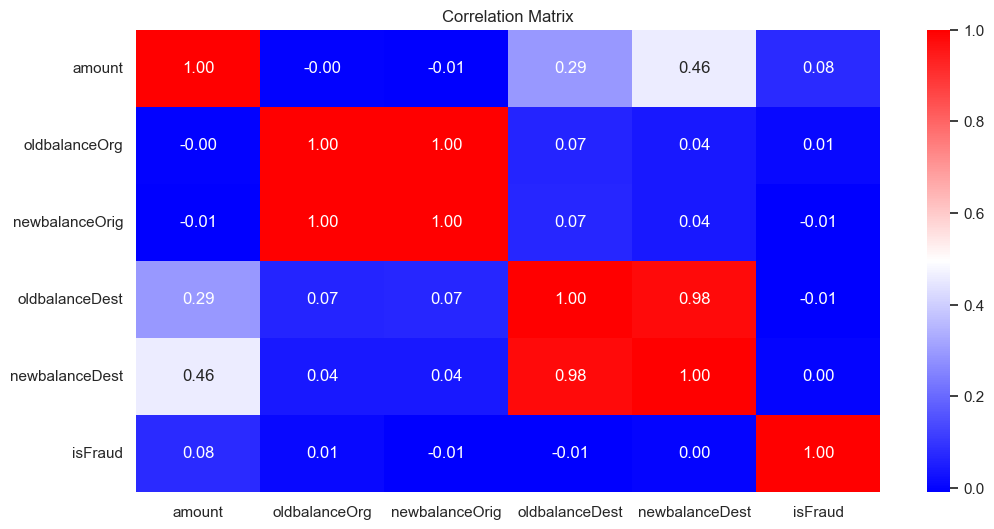

In [41]:
plt.figure(figsize=(12,6))
sns.heatmap(corr, annot=True, cmap= "bwr", fmt =".2f")
plt.title("Correlation Matrix", )
plt.show()

In [42]:
zero_after_transfer = df[
(df["oldbalanceOrg"]>0) &
(df["newbalanceOrig"] == 0 ) &
(df["type"].isin(["Transfer","Cash Out"]))

]

In [43]:
len(zero_after_transfer)

1188074

In [44]:
zero_after_transfer.head(5)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,Transfer,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,Cash Out,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,Cash Out,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,Transfer,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,Transfer,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [45]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [46]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report , confusion_matrix
from sklearn.pipeline import  Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor




In [48]:
df_model = df.drop(["nameOrig","nameDest", "isFlaggedFraud"], axis= 1 )

In [49]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,Payment,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,Payment,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,Transfer,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,Cash Out,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,Payment,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [50]:
categorical = ["type"]
numeric = ["amount", "oldbalanceOrg", "newbalanceOrig","oldbalanceDest","newbalanceDest"]

In [51]:
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis= 1 )


In [52]:
X_train, X_test, y_train , y_test = train_test_split(X,y, test_size=0.2, stratify=y)

In [122]:
preprocessor = ColumnTransformer(
    transformers=[
("num",StandardScaler(), numeric ),
("cat", OneHotEncoder(drop="first"), categorical)
],
remainder="drop"
)

In [142]:
pipeline = Pipeline([
("prep",preprocessor),
("clf",LogisticRegression(class_weight="balanced", max_iter=1000))


])

In [66]:
pipeline.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [53]:
df = pd.get_dummies(df, columns=["type"], drop_first=True)

In [54]:
X = df.drop(["isFraud", "isFlaggedFraud"], axis=1)
y = df["isFraud"]


In [130]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=200, stratify=y
)

In [131]:
X = df.drop(["isFraud", "isFlaggedFraud", "nameOrig", "nameDest"], axis=1)
y = df["isFraud"]

In [144]:
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=45, stratify=y
)

rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=45, n_jobs=-1)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [145]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, classification_report, confusion_matrix

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
print("Classification Report:", classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix: [[1906231      91]
 [    480    1984]]
Classification Report:               precision    recall  f1-score   support

           0     0.9997    1.0000    0.9999   1906322
           1     0.9561    0.8052    0.8742      2464

    accuracy                         0.9997   1908786
   macro avg     0.9779    0.9026    0.9370   1908786
weighted avg     0.9997    0.9997    0.9997   1908786

ROC-AUC: 0.9979034849773338


In [147]:
df = df.fillna(0)

In [148]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Skoru: 0.9979034849773338


In [ ]:
print("Classification Report:", classification_report(y_test, y_pred, digits=4))

Sınıflandırma Raporu:               precision    recall  f1-score   support

           0     0.9997    1.0000    0.9999   1906322
           1     0.9561    0.8052    0.8742      2464

    accuracy                         0.9997   1908786
   macro avg     0.9779    0.9026    0.9370   1908786
weighted avg     0.9997    0.9997    0.9997   1908786



In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("confusion matrix:", cm)

Hata Matrisi: [[1906231      91]
 [    480    1984]]


In [55]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

NameError: name 'roc_curve' is not defined

In [56]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(6,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

NameError: name 'precision_recall_curve' is not defined

In [ ]:
importances = rf.feature_importances_
feat_names = X.columns
feat_importance_df = pd.DataFrame({"feature": feat_names, "importance": importances})
feat_importance_df.sort_values(by="importance", ascending=False, inplace=True)

eng_replace= {
    "balanceDiffOrig": "Balance Diff",
    "oldbalanceOrg": "Old Balance",
    "newbalanceOrig": "New Balance",
    "amount": "Amount",
    "balanceDiffDest": "Destination Balance Difference",
    "type_Transfer": "Transfer",
    "type_Ödeme": "Payment",
    "newbalanceDest": "New Destination Balance",
    "type_Nakit Çıkışı": "Cash Out",
    "type_Nakit Girişi": "Cash In"
}


feat_importance_df["feature"] = feat_importance_df["feature"].map(eng_replace)
feat_importance_df_eng_replace = feat_importance_df[["feature_tr", "importance"]].rename(columns={"feature": "Feature", "importance": "Importance"})
top10 = feat_importance_df_eng_replace.head(10)

print(top10)


               Özellik      Önem
5         Bakiye Farkı  0.330134
1          Eski Bakiye  0.163715
2          Yeni Bakiye  0.124095
0                Tutar  0.116165
6   Hedef Bakiye Farkı  0.074569
9             Transfer  0.056108
10               Ödeme  0.047595
4    Hedef Yeni Bakiye  0.031730
8         Nakit Çıkışı  0.019875
7         Nakit Girişi  0.018223


In [ ]:
print("TOP 10 Features:", feat_importance_df_eng_replace.head(10))

TOP 10 Özellik:                Özellik      Önem
5         Bakiye Farkı  0.330134
1          Eski Bakiye  0.163715
2          Yeni Bakiye  0.124095
0                Tutar  0.116165
6   Hedef Bakiye Farkı  0.074569
9             Transfer  0.056108
10               Ödeme  0.047595
4    Hedef Yeni Bakiye  0.031730
8         Nakit Çıkışı  0.019875
7         Nakit Girişi  0.018223


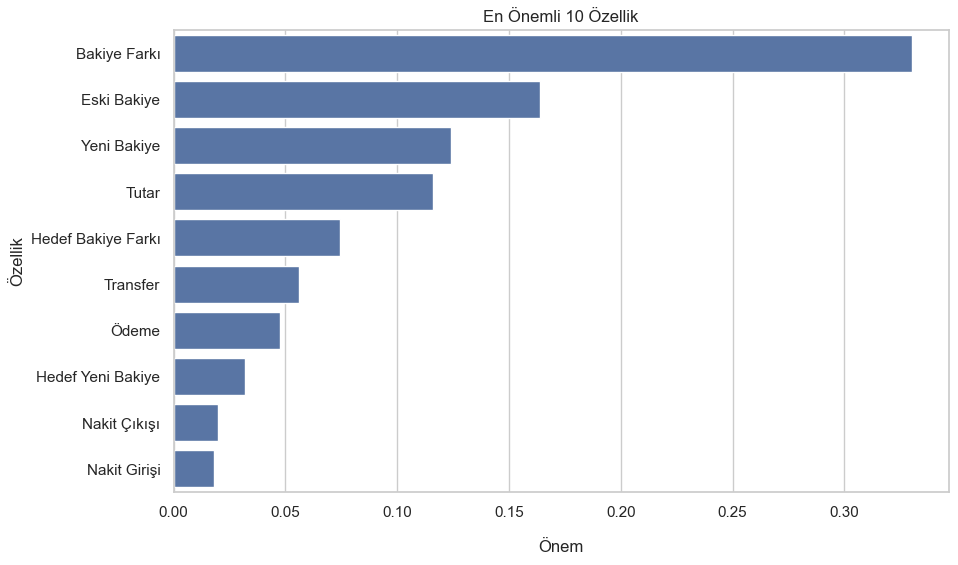

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=feat_importance_df.head(10),)
plt.title("TOP 10 Features")
plt.xlabel("Importance", labelpad=15)
plt.ylabel("Feature")
plt.show()

In [190]:
print(df.columns)

Index(['amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud',
       'balanceDiffOrig', 'balanceDiffDest', 'type_Nakit Girişi',
       'type_Nakit Çıkışı', 'type_Transfer', 'type_Ödeme'],
      dtype='object')


In [191]:
df_step = pd.read_csv("AIML Dataset.csv")[["step", "isFraud"]]

fraud_over_time = df_step[df_step["isFraud"]==1].groupby("step")["isFraud"].count()


In [163]:
import pickle
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])


In [192]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [193]:
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(pipeline, file)


In [194]:
import joblib
joblib.dump(pipeline,"fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']